Target N=899; stacked controls N=7603; n_controls=13


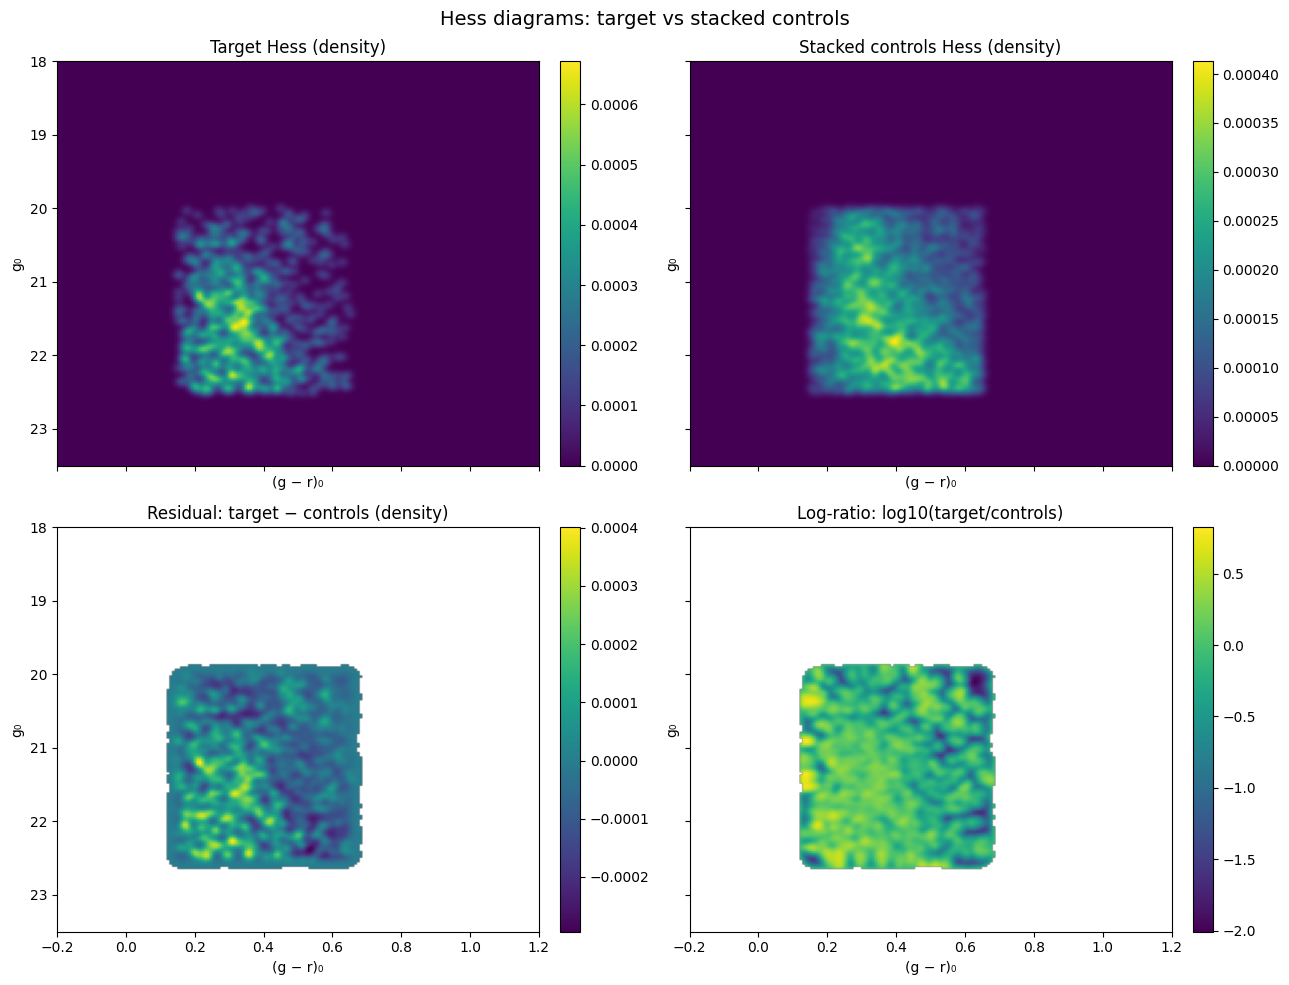

In [1]:
# Cell 1 — Hess diagram setup (target vs stacked controls) + residual (target - controls)

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

SIGMA_BINS = 1.5   # try 1.0–2.5; this is in "bin units"

# -----------------------------
# CONFIG
# -----------------------------
FIELDS_DIR = "sdss_data/fields"
PATTERN = os.path.join(FIELDS_DIR, "sdss_*.csv")

# CMD ranges (tune if you want to zoom)
C_MIN, C_MAX = -0.2, 1.2     # (g-r)0
G_MIN, G_MAX = 18.0, 23.5    # g0
NBIN_C, NBIN_G = 180, 180

# quality cuts (match your other notebooks)
ERR_MAX = 0.15
G0_MAX  = 23.5
R0_MAX  = 23.5

# Optional MSTO-only Hess (set True to restrict)
USE_MSTO_ONLY = True
msto = dict(gmin=20.0, gmax=22.5, cmin=0.15, cmax=0.65)

# Background floor to avoid crazy ratios in empty bins
EPS = 1e-6

# -----------------------------
# Load helper
# -----------------------------
def load_field_csv(path):
    df0 = pd.read_csv(path, comment="#")

    # dereddened mags/colors
    df0["g0"]  = df0["psfMag_g"] - df0["extinction_g"]
    df0["r0"]  = df0["psfMag_r"] - df0["extinction_r"]
    df0["g_r"] = df0["g0"] - df0["r0"]

    # errors
    df0["sig_g"]  = df0["psfMagErr_g"]
    df0["sig_r"]  = df0["psfMagErr_r"]
    df0["sig_gr"] = np.sqrt(df0["sig_g"]**2 + df0["sig_r"]**2)

    # light quality mask
    m = (
        (df0["sig_g"] < ERR_MAX) &
        (df0["sig_r"] < ERR_MAX) &
        (df0["g0"] < G0_MAX) &
        (df0["r0"] < R0_MAX)
    )
    df0 = df0[m].copy()

    if USE_MSTO_ONLY:
        mm = (
            (df0["g0"] >= msto["gmin"]) & (df0["g0"] <= msto["gmax"]) &
            (df0["g_r"] >= msto["cmin"]) & (df0["g_r"] <= msto["cmax"])
        )
        df0 = df0[mm].copy()

    return df0

# -----------------------------
# Read all fields
# -----------------------------
paths = sorted([p for p in glob.glob(PATTERN) if "FAILED_" not in os.path.basename(p)])
if not paths:
    raise FileNotFoundError(f"No files matched {PATTERN}")

fields = {}
for p in paths:
    fid = os.path.basename(p).replace("sdss_", "").replace(".csv", "")
    fields[fid] = load_field_csv(p)

if "target" not in fields:
    raise RuntimeError("No sdss_target.csv found (expected sdss_target.csv in fields dir).")

df_t = fields["target"]
df_c = pd.concat([df for fid, df in fields.items() if fid != "target"], ignore_index=True)

print(f"Target N={len(df_t)}; stacked controls N={len(df_c)}; n_controls={len(fields)-1}")

# -----------------------------
# Build Hess diagrams as densities (so different sample sizes are comparable)
# -----------------------------
# histogram2d uses x then y => (color, g0)
H_t, c_edges, g_edges = np.histogram2d(
    df_t["g_r"].to_numpy(), df_t["g0"].to_numpy(),
    bins=[NBIN_C, NBIN_G],
    range=[[C_MIN, C_MAX], [G_MIN, G_MAX]]
)
H_c, _, _ = np.histogram2d(
    df_c["g_r"].to_numpy(), df_c["g0"].to_numpy(),
    bins=[NBIN_C, NBIN_G],
    range=[[C_MIN, C_MAX], [G_MIN, G_MAX]]
)

# --- Smooth the Hess maps (smooth counts, not the already-normalized densities) ---
H_t_s = gaussian_filter(H_t, sigma=SIGMA_BINS, mode="nearest")
H_c_s = gaussian_filter(H_c, sigma=SIGMA_BINS, mode="nearest")

# Convert to densities (sum=1) AFTER smoothing
D_t = H_t_s / (H_t_s.sum() + EPS)
D_c = H_c_s / (H_c_s.sum() + EPS)

# Residual and log-ratio
RES  = D_t - D_c
LOGR = np.log10((D_t + EPS) / (D_c + EPS))

MIN_CTRL_DENS = 5e-7   # tune; smaller keeps more pixels
mask = D_c < MIN_CTRL_DENS

RES_plot  = np.ma.array(RES,  mask=mask)
LOGR_plot = np.ma.array(LOGR, mask=mask)

# Centers for plotting
c_cent = 0.5 * (c_edges[:-1] + c_edges[1:])
g_cent = 0.5 * (g_edges[:-1] + g_edges[1:])

extent = [C_MIN, C_MAX, G_MIN, G_MAX]

# -----------------------------
# Plot: target, controls, residual, log-ratio
# -----------------------------
fig, ax = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)

im0 = ax[0,0].imshow(D_t.T, origin="lower", aspect="auto", extent=extent)
ax[0,0].invert_yaxis()
ax[0,0].set_title("Target Hess (density)")

im1 = ax[0,1].imshow(D_c.T, origin="lower", aspect="auto", extent=extent)
ax[0,1].invert_yaxis()
ax[0,1].set_title("Stacked controls Hess (density)")

# im2 = ax[1,0].imshow(RES.T, origin="lower", aspect="auto", extent=extent)
im2 = ax[1,0].imshow(RES_plot.T, origin="lower", aspect="auto", extent=extent)
ax[1,0].invert_yaxis()
ax[1,0].set_title("Residual: target − controls (density)")

# im3 = ax[1,1].imshow(LOGR.T, origin="lower", aspect="auto", extent=extent)
im3 = ax[1,1].imshow(LOGR_plot.T, origin="lower", aspect="auto", extent=extent)
ax[1,1].invert_yaxis()
ax[1,1].set_title("Log-ratio: log10(target/controls)")

for a in ax.ravel():
    a.set_xlabel("(g − r)₀")
    a.set_ylabel("g₀")

# Colorbars (one per panel so you can interpret units)
fig.colorbar(im0, ax=ax[0,0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=ax[0,1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=ax[1,0], fraction=0.046, pad=0.04)
fig.colorbar(im3, ax=ax[1,1], fraction=0.046, pad=0.04)

# Optional: MSTO box overlay for context if not already restricting
if not USE_MSTO_ONLY:
    for a in ax.ravel():
        a.axvline(msto["cmin"], lw=1)
        a.axvline(msto["cmax"], lw=1)
        a.axhline(msto["gmin"], lw=1)
        a.axhline(msto["gmax"], lw=1)

plt.suptitle("Hess diagrams: target vs stacked controls", y=0.98, fontsize=14)
plt.tight_layout()
plt.show()

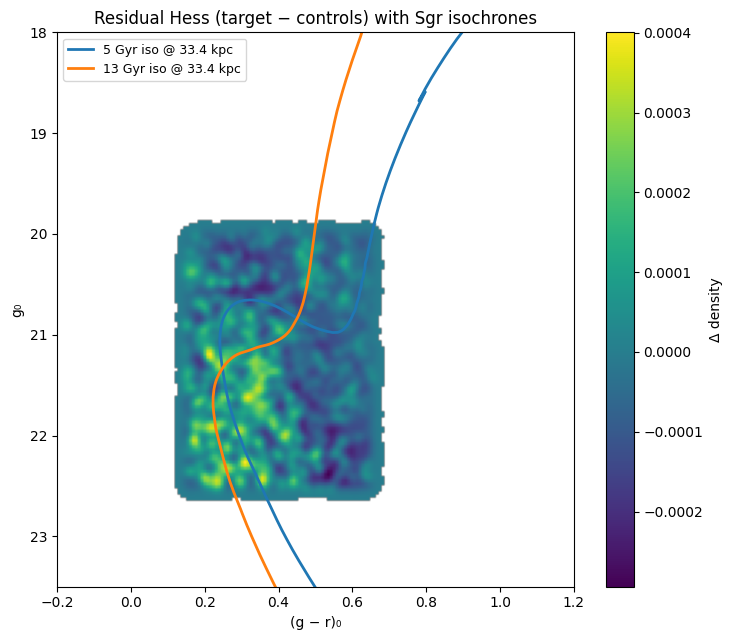

In [2]:
# Cell 2 — Overlay the two Sgr isochrones on the Hess residual plot (optional but recommended)

import numpy as np
import matplotlib.pyplot as plt

# Sgr reference distance
d_pc = 33_400.0
DM_SGR = 5.0 * np.log10(d_pc / 10.0)

# Load Dartmouth isochrones (uses your existing loader)
from isochrones.dartmouth_iso import load_isochrones
isos = load_isochrones("isochrones")
iso5  = isos["5gyr"]
iso13 = isos["13gyr"]

def iso_to_apparent_arrays(iso, DM):
    df_iso = iso.df
    g_app = df_iso["sdss_g"].to_numpy() + DM
    r_app = df_iso["sdss_r"].to_numpy() + DM
    c_app = g_app - r_app
    return c_app, g_app

c5,  g5  = iso_to_apparent_arrays(iso5,  DM_SGR)
c13, g13 = iso_to_apparent_arrays(iso13, DM_SGR)

# Replot residual panel with isochrone overlays
plt.figure(figsize=(7.5, 6.5))
# plt.imshow(RES.T, origin="lower", aspect="auto", extent=[C_MIN, C_MAX, G_MIN, G_MAX])
plt.imshow(RES_plot.T, origin="lower", aspect="auto", extent=[C_MIN, C_MAX, G_MIN, G_MAX])
plt.gca().invert_yaxis()
plt.plot(c5,  g5,  lw=2, label="5 Gyr iso @ 33.4 kpc", alpha=1)
plt.plot(c13, g13, lw=2, label="13 Gyr iso @ 33.4 kpc", alpha=1)
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.xlim(-0.2, 1.2)
plt.ylim(23.5, 18)
plt.title("Residual Hess (target − controls) with Sgr isochrones")
plt.colorbar(label="Δ density")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()